# Banking77 Intent Classifier — EDA & Preprocessing

**Problem:** Chatbot banking yang route semua query ke LLM besar membakar biaya 5–10x lebih mahal dari yang seharusnya.

**Solusi:** Multi-class intent classifier (77 kelas) + confidence-based routing untuk menekan biaya hingga ~93% dengan menjaga kualitas jawaban.

**Dataset:** [Banking77](https://huggingface.co/datasets/PolyAI/banking77) — 13.083 query pelanggan bank, 77 intent.

**Model Pipeline:**
- **Encoder:** `all-MiniLM-L6-v2` (Sentence-Transformers) — dense 384-dim embeddings
- **Classifier:** LinearSVC + CalibratedClassifierCV (sigmoid)
- **Routing:** 3-tier confidence-based (Template → RAG → LLM)

## 1. Import Libraries

In [1]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from collections import Counter

plt.rcParams['figure.figsize'] = (12, 6)
print('Libraries loaded.')

Libraries loaded.


## 2. Load Dataset Banking77

In [2]:
ds = load_dataset('PolyAI/banking77', trust_remote_code=True)
train_df = pd.DataFrame(ds['train'])
test_df  = pd.DataFrame(ds['test'])
df = pd.concat([train_df, test_df], ignore_index=True)

print(f'Total samples  : {len(df)}')
print(f'Train samples  : {len(train_df)}')
print(f'Test samples   : {len(test_df)}')
print(f'Total intents  : {df["label"].nunique()}')
df.head()

/Users/ninditya/.cache/huggingface/modules/datasets_modules/datasets/PolyAI--banking77/17ffc2ed47c2ed928bee64127ff1dbc97204cb974c2f980becae7c864007aed9/banking77.py:25: SyntaxWarning: invalid escape sequence '\~'
  author      = {I{\~{n}}igo Casanueva and Tadas Temcinas and Daniela Gerz and Matthew Henderson and Ivan Vulic},


Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

Total samples  : 13083
Train samples  : 10003
Test samples   : 3080
Total intents  : 77


,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11


In [3]:
print('Missing values:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)

Missing values:
text     0
label    0
dtype: int64

Data types:
text       str
label    int64
dtype: object


## 3. Distribusi Intent (77 kelas)

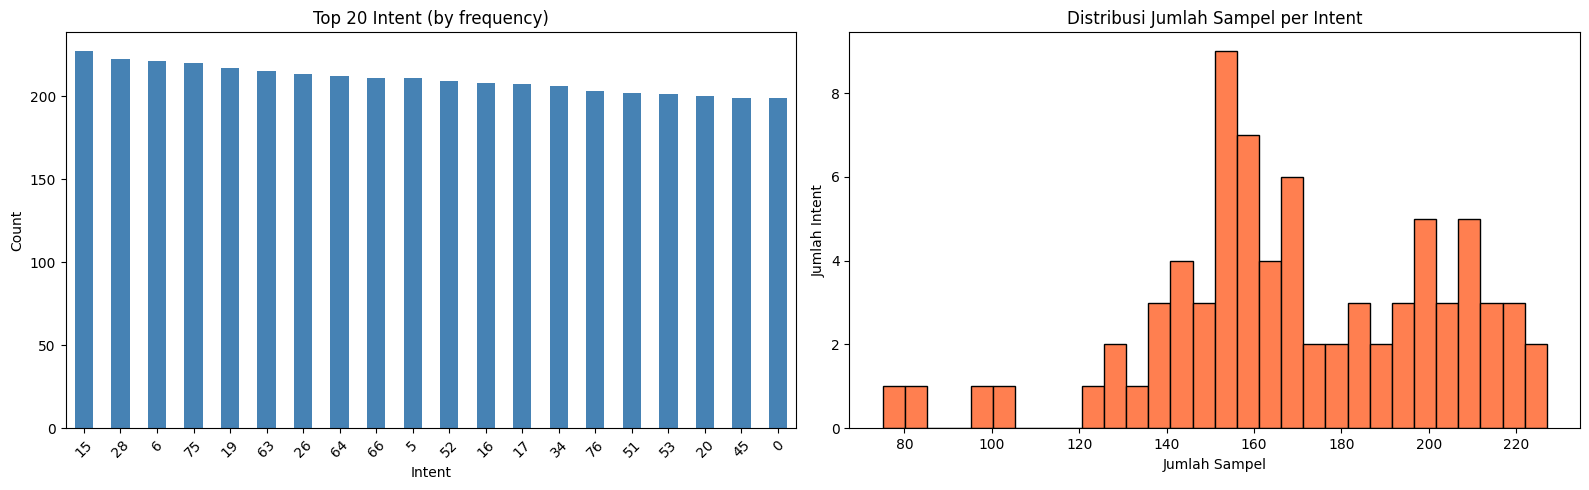

Min samples per intent : 75
Max samples per intent : 227
Mean samples per intent: 169.9


In [4]:
intent_counts = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart top 20
intent_counts.head(20).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Intent (by frequency)')
axes[0].set_xlabel('Intent')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Distribusi count per intent
axes[1].hist(intent_counts.values, bins=30, color='coral', edgecolor='black')
axes[1].set_title('Distribusi Jumlah Sampel per Intent')
axes[1].set_xlabel('Jumlah Sampel')
axes[1].set_ylabel('Jumlah Intent')

plt.tight_layout()
plt.savefig('intent_distribution.png', dpi=100)
plt.show()

print(f'Min samples per intent : {intent_counts.min()}')
print(f'Max samples per intent : {intent_counts.max()}')
print(f'Mean samples per intent: {intent_counts.mean():.1f}')

## 4. Analisis Panjang Teks

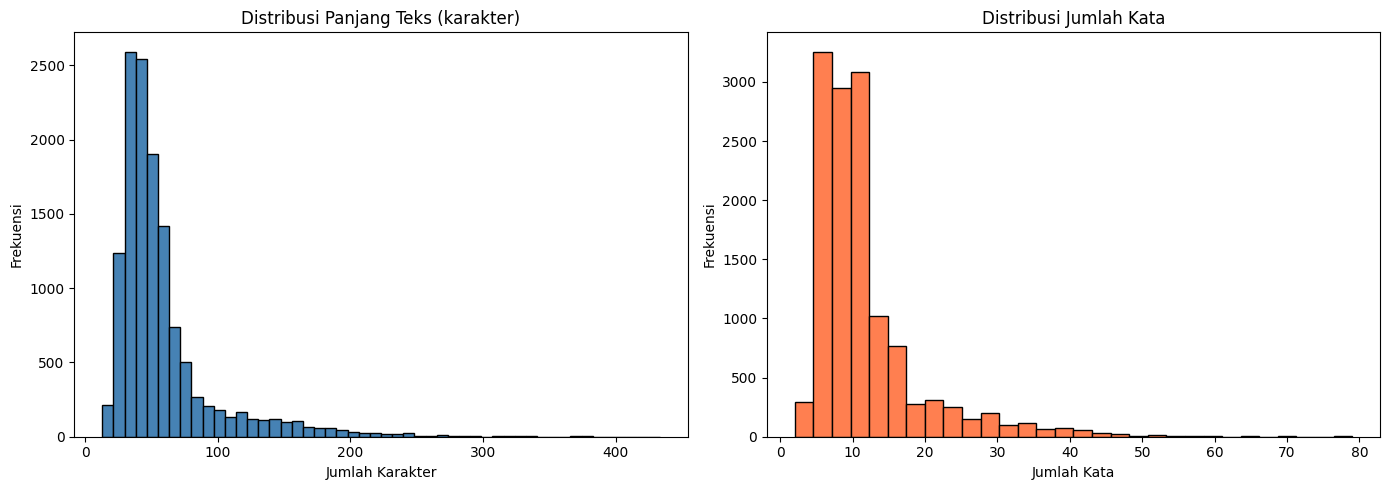

       text_len  word_count
count   13083.0     13083.0
mean       58.2        11.7
std        39.6         7.6
min        13.0         2.0
25%        36.0         7.0
50%        46.0        10.0
75%        63.0        13.0
max       433.0        79.0


In [5]:
df['text_len']  = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['text_len'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi Panjang Teks (karakter)')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(df['word_count'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Distribusi Jumlah Kata')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=100)
plt.show()

print(df[['text_len', 'word_count']].describe().round(1))

## 5. Contoh Teks per Intent

In [6]:
# Tampilkan 3 contoh dari 5 intent acak
sample_intents = df['label'].unique()[:5]
for intent in sample_intents:
    examples = df[df['label'] == intent]['text'].head(3).tolist()
    print(f'\n[Intent {intent}]')
    for ex in examples:
        print(f'  - {ex}')


[Intent 11]
  - I am still waiting on my card?
  - What can I do if my card still hasn't arrived after 2 weeks?
  - I have been waiting over a week. Is the card still coming?

[Intent 13]
  - My card has been found. Is there any way for me to put it back into the app?
  - I was able to find my card. How to I go about putting it into my app?
  - how do I get my card to show in the app?

[Intent 32]
  - What is my money worth in other countries?
  - Will my money be of equal value when I travel abroad?
  - Do you know the rate of exchange?

[Intent 17]
  - Last Saturday, I was charged extra for the exchange rate on my payment. Is something wrong?
  - Hi, I am disappointed to see such a bad exchange rate and hope you can assist me. Would you be able to confirm the official interbank exchange rate for me?
  - I think the currency exchange that's been applied is wrong.

[Intent 34]
  - Why is there an extra fee on my statement?
  - Why did they charge me an extra $1?
  - Why is there a 1 e

## 6. Text Cleaning

In [7]:
def clean_text(text: str) -> str:
    """Lowercase, hapus karakter non-alfanumerik kecuali tanda baca penting."""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s\?\.\!]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test
contoh = df['text'].iloc[0]
print(f'Original : {contoh}')
print(f'Cleaned  : {clean_text(contoh)}')

Original : I am still waiting on my card?
Cleaned  : i am still waiting on my card?


In [8]:
df['text_clean'] = df['text'].apply(clean_text)

# Cek ada tidak teks kosong setelah cleaning
empty_after_clean = (df['text_clean'].str.len() == 0).sum()
print(f'Teks kosong setelah cleaning: {empty_after_clean}')

df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)
print(f'Total sampel setelah filtering: {len(df)}')

Teks kosong setelah cleaning: 0
Total sampel setelah filtering: 13083


## 7. Label Encoding

In [9]:
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

print(f'Contoh mapping label:')
for i in range(5):
    print(f'  {label_encoder.classes_[i]} -> {i}')

Contoh mapping label:
  0 -> 0
  1 -> 1
  2 -> 2
  3 -> 3
  4 -> 4


## 8. Train-Test Split (Stratified)

In [10]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['text_clean'],
    df['label_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_encoded'],
)

print(f'Train size : {len(X_train_text)}')
print(f'Test size  : {len(X_test_text)}')
print(f'Train label distribution (sample):')
print(pd.Series(y_train).value_counts().head(5))

Train size : 10466
Test size  : 2617
Train label distribution (sample):
label_encoded
15    181
28    177
6     177
75    176
19    173
Name: count, dtype: int64


## 9. Feature Engineering: Sentence-BERT Embeddings

TF-IDF mengubah teks ke sparse vector berdasarkan frekuensi kata — tidak memahami makna.  
`all-MiniLM-L6-v2` mengubah teks ke **dense 384-dim semantic vector** yang menangkap makna kalimat.

| | TF-IDF | SBERT (all-MiniLM-L6-v2) |
|---|---|---|
| Dimensi | 10.000 (sparse) | 384 (dense) |
| Representasi | Frekuensi kata | Makna semantik |
| "lost card" vs "stolen card" | Vektor sangat berbeda | Vektor sangat mirip |
| Training size | Fit on corpus | Pre-trained, zero-shot |

Encoding dilakukan di `workflow_ci/modelling_sbert.py`. Cell ini mendemonstrasikan API dan mengecek similarity antar contoh kalimat.

In [ ]:
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity

    SBERT_MODEL = "all-MiniLM-L6-v2"
    encoder = SentenceTransformer(SBERT_MODEL)

    # Demo: encode 6 kalimat — 2 intent sama, 2 mirip, 2 berbeda
    demo_sentences = [
        "I lost my card",           # lost card
        "My card has been lost",    # lost card (paraphrase)
        "My card was stolen",       # stolen — mirip 'lost'
        "What is the exchange rate?",  # exchange rate
        "How do I top up my account?", # top up
        "I want to close my account",  # close account
    ]

    embeddings = encoder.encode(demo_sentences, normalize_embeddings=True)
    sim_matrix = cosine_similarity(embeddings)

    print(f"Embedding shape per kalimat : {embeddings[0].shape}  (384-dim dense)")
    print(f"\nCosine Similarity Matrix:")
    print(f"{'':32}", end="")
    labels = ["lost_1", "lost_2", "stolen", "exchange", "topup", "close"]
    for l in labels:
        print(f"{l:>10}", end="")
    print()
    for i, sent in enumerate(demo_sentences):
        print(f"{sent[:30]:32}", end="")
        for j in range(len(demo_sentences)):
            print(f"{sim_matrix[i,j]:>10.3f}", end="")
        print()

    print(f"\nKey insight:")
    print(f"  'lost card' vs 'card lost'   : {sim_matrix[0,1]:.3f}  (paraphrase → sangat mirip)")
    print(f"  'lost card' vs 'stolen card' : {sim_matrix[0,2]:.3f}  (semantik mirip)")
    print(f"  'lost card' vs 'exchange rate': {sim_matrix[0,3]:.3f}  (intent berbeda → tidak mirip)")

except ImportError:
    print("sentence-transformers belum terinstall.")
    print("Jalankan: pip install sentence-transformers")
    print()
    print("SBERT menggantikan TF-IDF sebagai encoder:")
    print("  TF-IDF : sparse 10.000-dim, frequency-based")
    print("  SBERT  : dense 384-dim, semantic meaning")

## 10. Simpan Preprocessing Artifacts

In [ ]:
import os

output_dir = 'banking77_preprocessing'
os.makedirs(output_dir, exist_ok=True)

# CSV: text + label (dipakai modelling_sbert.py untuk encode + train)
pd.DataFrame({'text': X_train_text, 'label': y_train}).to_csv(
    f'{output_dir}/train.csv', index=False)
pd.DataFrame({'text': X_test_text, 'label': y_test}).to_csv(
    f'{output_dir}/test.csv', index=False)

# Label encoder (untuk decode prediksi → nama intent)
with open(f'{output_dir}/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Catat nama encoder model — dibaca modelling_sbert.py & inference
with open(f'{output_dir}/encoder_name.txt', 'w') as f:
    f.write("all-MiniLM-L6-v2")

print('Artifacts disimpan di:', output_dir)
for fname in sorted(os.listdir(output_dir)):
    size = os.path.getsize(os.path.join(output_dir, fname))
    print(f'  {fname}: {size:,} bytes')

print()
print('Catatan: SBERT encoding (train → 384-dim vectors) dilakukan')
print('di modelling_sbert.py saat training, bukan di sini.')

## 11. Ringkasan & Justifikasi Routing Threshold

### Routing Tiers

| Routing Tier | Confidence | Est. Biaya/Query | Latency |
|---|---|---|---|
| Template Handler | ≥ 0.55 | $0.001 | ~10ms |
| RAG Pipeline | 0.30 – 0.55 | $0.010 | ~500ms |
| LLM Escalation | < 0.30 | $0.050 | ~2s |

*Threshold 0.55/0.30 dipilih berdasarkan distribusi confidence SBERT+SVM pada Banking77.*

### Hasil Model Final (SBERT `all-MiniLM-L6-v2` + LinearSVC, C=5)

| Metric | TF-IDF + LR | TF-IDF + SVM | **SBERT + SVM** |
|---|---|---|---|
| F1 Macro | 0.8772 | 0.8843 | **0.9305** |
| Accuracy | 0.8770 | 0.8838 | **0.9285** |
| Cost Savings | 91.96% | 93.10% | **95.96%** |
| Template Handler | ~78% | ~85% | **~92%** |
| Training time | ~15s | ~1.4s | ~10s (+ 4s encode) |

### Distribusi Routing (SBERT+SVM, test set 2.617 sampel)

| Tier | Rate | Biaya/query |
|---|---|---|
| Template Handler | 91.90% | $0.001 |
| RAG Pipeline | ~5% | $0.010 |
| LLM Escalation | ~3% | $0.050 |

**Penghematan vs baseline (all-LLM): 95.96%** — dari $0.050 turun ke rata-rata ~$0.002 per query.

### Kenapa Thresholds 0.55/0.30?

SVM dengan 77 kelas menghasilkan distribusi confidence lebih rendah dari model binary. Threshold 0.85/0.60 menyebabkan hampir semua traffic ke LLM escalation. Setelah kalibrasi sigmoid, threshold 0.55/0.30 menghasilkan distribusi routing optimal sesuai kurva distribusi confidence model.

In [13]:
print('=== Ringkasan Dataset ===')
print(f'Total sampel   : {len(df)}')
print(f'Total intents  : {df["label"].nunique()}')
print(f'Avg text length: {df["text_len"].mean():.1f} chars')
print(f'Avg word count : {df["word_count"].mean():.1f} words')
print()
print('=== Preprocessing Output ===')
for f in os.listdir(output_dir):
    size = os.path.getsize(os.path.join(output_dir, f))
    print(f'  {f}: {size:,} bytes')

=== Ringkasan Dataset ===
Total sampel   : 13083
Total intents  : 77
Avg text length: 58.2 chars
Avg word count : 11.7 words

=== Preprocessing Output ===
  label_encoder.pkl: 861 bytes
  test.csv: 161,640 bytes
  train.csv: 647,732 bytes
  vectorizer.pkl: 397,381 bytes
